# ML Modeling: Linear Regression Analysis for GDM Association

## Overview
This notebook performs linear regression analysis to determine if there is a significant difference in metabolite levels between GDM positive and non-GDM women, while accounting for covariates. We will analyze cord blood metabolites and calculate effect sizes and adjusted p-values.

## Step 1-2: Set Up Big Loop for Each Metabolite (Cord Data)

We will create a loop that iterates over each metabolite. For cord data:
- Rows = samples  
- Columns = metabolites  
- For each metabolite i: extract metabolite[i] (all rows, ith column)
- Fit model: `lm(metabolite[i] ~ covariates)`

## Setup: Load Core Inputs (Self-Contained)

Loading:
- `cord_matrix` from `CORD_DATA_T`
- covariates and supplements from `src/raw/mata2022_caco_mar242022.xlsx`
- `Sample` IDs from the cord mapping file (for row alignment only)
- `covariate_matrix_num` (aligned to cord sample order)
- `ml_csv_dir` for outputs

In [49]:
# Self-contained setup: load metabolite matrix and build aligned covariate matrix
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Keep imports robust for notebook cwd differences
sys.path.insert(0, str(Path(os.getcwd()).parent.parent))
from src.utils.config import CORD_DATA_T, CORD_ANNO, OUTPUTS_DIR

# 1) Load cord metabolite matrix (rows=samples, columns=metabolites)
cord_matrix = pd.read_csv(CORD_DATA_T, index_col="Sample").astype(float)
cord_matrix.index = cord_matrix.index.astype(str)

# 2) Load raw maternal covariate file (source of supplements + lifestyle covariates)
src_dir = Path(CORD_DATA_T).resolve().parents[2]
mata_path = src_dir / "raw" / "mata2022_caco_mar242022.xlsx"
if not mata_path.exists():
    raise FileNotFoundError(f"Required maternal covariate file not found: {mata_path}")

mata_df = pd.read_excel(mata_path)

# 3) Load Sample ID bridge from cord mapping output (used only for sample alignment)
gdm_map_path = os.path.join(OUTPUTS_DIR, "pca", "output_csv", "06_pc_scores", "cord_mapped_with_pc1_pc2.csv")
if not os.path.exists(gdm_map_path):
    raise FileNotFoundError(f"Required mapping file not found: {gdm_map_path}")

sample_bridge = pd.read_csv(gdm_map_path)
required_bridge_cols = ["Sample", "IDCode"]
missing_bridge = [c for c in required_bridge_cols if c not in sample_bridge.columns]
if missing_bridge:
    raise ValueError(f"Mapping file missing required columns: {missing_bridge}")

sample_bridge = sample_bridge[required_bridge_cols].copy()
sample_bridge["Sample"] = sample_bridge["Sample"].astype(str).str.strip()
sample_bridge = sample_bridge[sample_bridge["Sample"].str.len() > 0]
sample_bridge["IDCode"] = pd.to_numeric(sample_bridge["IDCode"], errors="coerce")
sample_bridge = sample_bridge.dropna(subset=["IDCode"]).drop_duplicates(subset=["Sample"], keep="first")

# 4) Merge raw maternal covariates to Sample IDs via IDCode
map_df = sample_bridge.merge(mata_df, on="IDCode", how="left")
map_df = map_df.drop_duplicates(subset=["Sample"], keep="first").set_index("Sample")

# 5) Resolve required covariates by aliases
covariate_aliases = {
    "maternal_age": ["Ma_age", "maternal_age"],
    "bmi": ["pre_BMI_new", "BMI", "Ma_BMI"],
    "diet_protein": ["diet_protein", "protein", "protein_intake"],
    "diet_fruit_vegetables": ["diet_vegfruit", "fruit_vegetable", "fruit_veg"],
    "physical_activity": ["O2_PHYSACTIV", "physical_activity", "phys_activity", "O1_JOBACTIVITY"],
}

supplement_aliases = {
    "supp_multivitamin": ["p4_MULTIVITAMIN", "multivitamin"],
    "supp_calcium": ["p4_CALCIUM", "calcium"],
    "supp_folate": ["p4_FOLATE", "folate", "folic_acid"],
    "supp_fishoil": ["p4_FISHOIL", "fishoil", "fish_oil"],
    "supp_zinc": ["p4_ZINC", "zinc"],
    "supp_vitamin_e": ["p4_VITE", "vitamin_e", "vite"],
}

selected_covariates = {}
for label, aliases in covariate_aliases.items():
    selected = next((col for col in aliases if col in map_df.columns), None)
    if selected is not None:
        selected_covariates[label] = selected

if not selected_covariates:
    raise ValueError("None of the requested numeric covariates were found in maternal covariate file.")

selected_supplements = {}
for label, aliases in supplement_aliases.items():
    selected = next((col for col in aliases if col in map_df.columns), None)
    if selected is not None:
        selected_supplements[label] = selected

missing_supps = [k for k in supplement_aliases if k not in selected_supplements]
if missing_supps:
    raise ValueError(f"Missing supplement columns required for derived variables: {missing_supps}")

# 6) Align covariate rows to cord matrix row order
sample_order = cord_matrix.index
ordered_source_cols = ["GDM"] + list(selected_covariates.values())
if "GDM" not in map_df.columns:
    raise ValueError("GDM column not found after merging maternal covariates.")

covariate_matrix_raw = map_df.reindex(sample_order)[ordered_source_cols].copy()
covariate_matrix_raw.index.name = "Sample"

rename_map = {"GDM": "GDM"}
rename_map.update({src: label for label, src in selected_covariates.items()})
covariate_matrix_raw = covariate_matrix_raw.rename(columns=rename_map)

# 7) Build supplement-derived variables
supplement_source_df = map_df.reindex(sample_order)[list(selected_supplements.values())].copy()
supplement_source_df = supplement_source_df.rename(columns={v: k for k, v in selected_supplements.items()})


def to_binary_use(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    observed = set(s.dropna().unique())
    if not observed:
        return pd.Series(np.nan, index=s.index, dtype=float)
    if observed.issubset({1, 2}):
        return s.map({1: 0.0, 2: 1.0})
    if observed.issubset({0, 1}):
        return s.astype(float)
    out = np.where(s.isna(), np.nan, (s > 0).astype(float))
    return pd.Series(out, index=s.index, dtype=float)

supp_binary = supplement_source_df.apply(to_binary_use)

core3_cols = ["supp_multivitamin", "supp_calcium", "supp_folate"]
all6_cols = [
    "supp_multivitamin", "supp_calcium", "supp_folate",
    "supp_fishoil", "supp_zinc", "supp_vitamin_e",
]

core3_df = supp_binary[core3_cols]
all6_df = supp_binary[all6_cols]

core3_any = (core3_df == 1).any(axis=1).astype(float)
core3_all_missing = core3_df.isna().all(axis=1)
all6_any = (all6_df == 1).any(axis=1).astype(float)
all6_all_missing = all6_df.isna().all(axis=1)

covariate_matrix_raw["supp_any_mvf_ca_fol"] = np.where(core3_all_missing, np.nan, core3_any)
covariate_matrix_raw["supp_any_of_6"] = np.where(all6_all_missing, np.nan, all6_any)

# 8) Type handling: GDM categorical binary (0/1), others numeric
covariate_matrix_num = covariate_matrix_raw.copy()
gdm_numeric = pd.to_numeric(covariate_matrix_num["GDM"], errors="coerce")
covariate_matrix_num["GDM"] = pd.Categorical(gdm_numeric, categories=[0, 1])

numeric_covariates = [c for c in covariate_matrix_num.columns if c != "GDM"]
covariate_matrix_num[numeric_covariates] = covariate_matrix_num[numeric_covariates].apply(pd.to_numeric, errors="coerce")

# Store covariates in the requested variable name
cov_matrix = covariate_matrix_num.copy()

# 9) Output directory for this analysis
ml_csv_dir = os.path.join(OUTPUTS_DIR, "ml_modeling", "output_csv", "08_cord_gdm")
os.makedirs(ml_csv_dir, exist_ok=True)

print("Setup complete")
print("Cord matrix shape:", cord_matrix.shape)
print("Covariate matrix shape:", cov_matrix.shape)
print("GDM dtype:", cov_matrix["GDM"].dtype)
print("Resolved numeric covariates:", numeric_covariates)
print("Maternal source file:", mata_path)
print("Output dir:", ml_csv_dir)

Setup complete
Cord matrix shape: (38, 981)
Covariate matrix shape: (38, 8)
GDM dtype: category
Resolved numeric covariates: ['maternal_age', 'bmi', 'diet_protein', 'diet_fruit_vegetables', 'physical_activity', 'supp_any_mvf_ca_fol', 'supp_any_of_6']
Maternal source file: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/raw/mata2022_caco_mar242022.xlsx
Output dir: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/output_csv/08_cord_gdm


In [57]:
cord_matrix.head()

,107004,108005,109011,1101001,1101006,1102005,1102011,1102012,1102017,1102018,...,675024,675025,675026,675027,675028,675029,676007,677004,677011,634009
Sample,,,,,,,,,,,,,,,,,,,,,
sample-1,0.982920,0.997001,1.001218,1.001201,1.040406,1.000000,0.979128,0.897300,1.049986,0.918842,...,0.998943,0.995692,0.993673,1.006100,0.989948,0.995593,0.990328,0.977754,0.985770,0.976144
sample-2,0.991572,1.024139,1.014588,1.019298,0.853199,0.881035,1.010385,0.931008,1.059620,0.908615,...,1.001057,0.996019,1.003748,0.992310,1.000658,0.994897,1.012718,1.005144,1.000231,1.017369
sample-3,0.962144,0.972625,0.999607,0.891771,0.953293,1.001158,0.869336,0.897300,0.834241,0.908615,...,0.988019,0.990972,0.980308,0.982788,0.994468,0.983981,1.004100,0.979684,0.980854,0.961003
sample-4,1.005908,1.015966,1.000671,0.891771,0.853199,1.022224,0.869336,0.897300,0.943810,0.908615,...,0.983763,0.985011,0.993704,0.997537,0.998984,0.989069,1.023485,0.991362,0.981521,0.983039
sample-5,0.888982,0.989501,0.995799,1.092085,0.925969,1.022152,0.869336,0.897300,0.915130,0.908615,...,1.013374,1.007367,0.996035,0.987062,0.997701,1.008544,0.935841,0.986891,0.995214,0.979196


In [44]:
# Step 3: Load and Preview Cord Metabolite Data
# Load cord metabolite matrix (rows=samples, columns=metabolites)

cord_matrix = pd.read_csv(CORD_DATA_T, index_col="Sample").astype(float)
cord_matrix.index = cord_matrix.index.astype(str)

# Verify the data loaded correctly
print("Cord metabolite data shape:", cord_matrix.shape)
print("First 10 metabolite names:", cord_matrix.columns[:10])  # Show first 10 metabolite names
print("Cord data samples:", cord_matrix.index)


Cord metabolite data shape: (38, 981)
First 10 metabolite names: Index(['107004', '108005', '109011', '1101001', '1101006', '1102005',
       '1102011', '1102012', '1102017', '1102018'],
      dtype='object')
Cord data samples: Index(['sample-1', 'sample-2', 'sample-3', 'sample-4', 'sample-5', 'sample-6',
       'sample-7', 'sample-8', 'sample-9', 'sample-10', 'sample-11',
       'sample-12', 'sample-13', 'sample-14', 'sample-15', 'sample-16',
       'sample-17', 'sample-18', 'sample-19', 'sample-20', 'sample-21',
       'sample-22', 'sample-23', 'sample-24', 'sample-25', 'sample-26',
       'sample-27', 'sample-28', 'sample-29', 'sample-30', 'sample-31',
       'sample-32', 'sample-33', 'sample-34', 'sample-35', 'sample-36',
       'sample-37', 'sample-38'],
      dtype='object', name='Sample')


## Step 4: Create Covariate Matrix

Create a matrix of covariates that associates with cord blood samples. The order must match the metabolite data.

**Covariates to include:**
- Maternal age
- BMI
- Diet (protein, fruit&vegetables)
- Physical activity
- Supplements (special handling):
  - **Variable 1:** Any of (Multivitamin, Calcium, Folate) = 1, else 0
  - **Variable 2:** Any of all 6 (Multivitamin, Calcium, Folate, Fishoil, Zinc, Vitamin E) = 1, else 0

In [56]:
# Step 4: Create covariate matrix aligned with cord samples
# cov_matrix = covariates that associate with the samples of cord blood
# Must be ordered in the same way as cord_matrix (rows match by sample ID)

# Verify covariate data is loaded and aligned
print("Covariate matrix shape:", cov_matrix.shape)
print("Covariate columns:", cov_matrix.columns.tolist())
print("Number of samples in covariates:", len(cov_matrix))

# Check alignment: cord samples vs covariate samples
cord_samples = set(cord_matrix.index)
cov_samples = set(cov_matrix.index)

print(f"\nCord samples: {len(cord_samples)}")
print(f"Covariate samples: {len(cov_samples)}")
print(f"Overlap: {len(cord_samples & cov_samples)}")

Covariate matrix shape: (38, 8)
Covariate columns: ['GDM', 'maternal_age', 'bmi', 'diet_protein', 'diet_fruit_vegetables', 'physical_activity', 'supp_any_mvf_ca_fol', 'supp_any_of_6']
Number of samples in covariates: 38

Cord samples: 38
Covariate samples: 38
Overlap: 38


In [55]:
cov_matrix.head()

,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity,supp_any_mvf_ca_fol,supp_any_of_6
Sample,,,,,,,,
sample-1,0,34,28.040378,4.50,4.5,2.0,1.0,1.0
sample-2,1,28,25.217359,3.25,4.5,2.0,1.0,1.0
sample-3,0,28,24.242424,12.50,12.5,2.0,1.0,1.0
sample-4,1,37,22.375680,8.50,24.0,1.0,1.0,1.0
sample-5,0,32,20.195578,30.00,30.0,2.0,NaN,NaN


## Step 5: Check for Missing Covariates and Data Cleaning

- Drop rows/samples with missing covariates
- Expected: 4 samples have missing values → should drop 4 columns, leaving 34 out of 38 samples
- Ensure all numeric covariates are numeric data type (no strings)
- GDM should be a binary categorical variable (0 & 1) modeled as a factor

In [65]:
# Step 5: Check for missing covariates and clean data
import numpy as np

# Check for missing values in covariate matrix
print("Missing values by covariate:")
print(covariate_matrix_num.isnull().sum())
print(f"\nTotal missing values: {covariate_matrix_num.isnull().sum().sum()}")


Missing values by covariate:
GDM                      0
maternal_age             0
bmi                      0
diet_protein             1
diet_fruit_vegetables    1
physical_activity        3
supp_any_mvf_ca_fol      3
supp_any_of_6            3
dtype: int64

Total missing values: 11


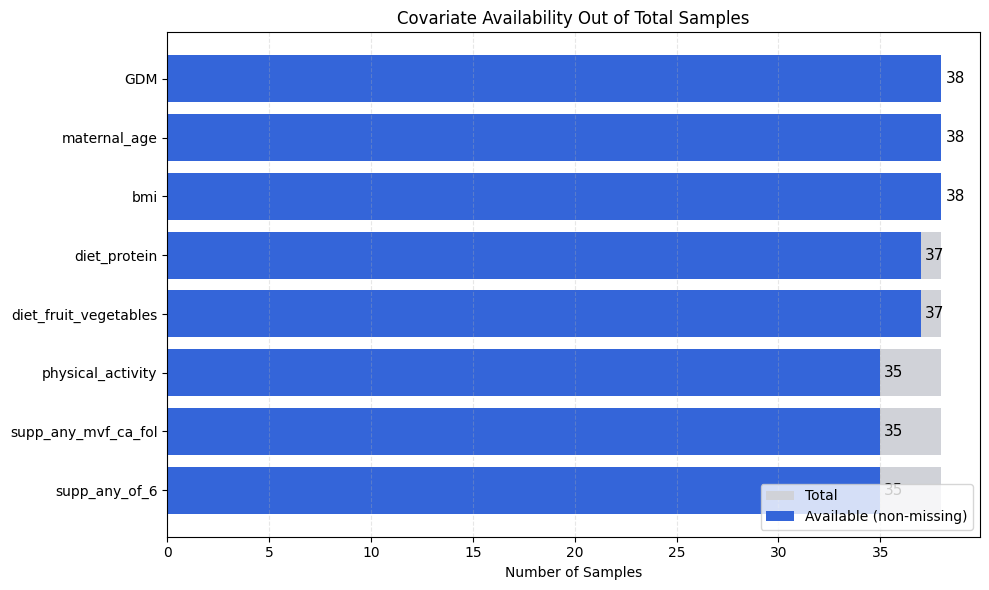

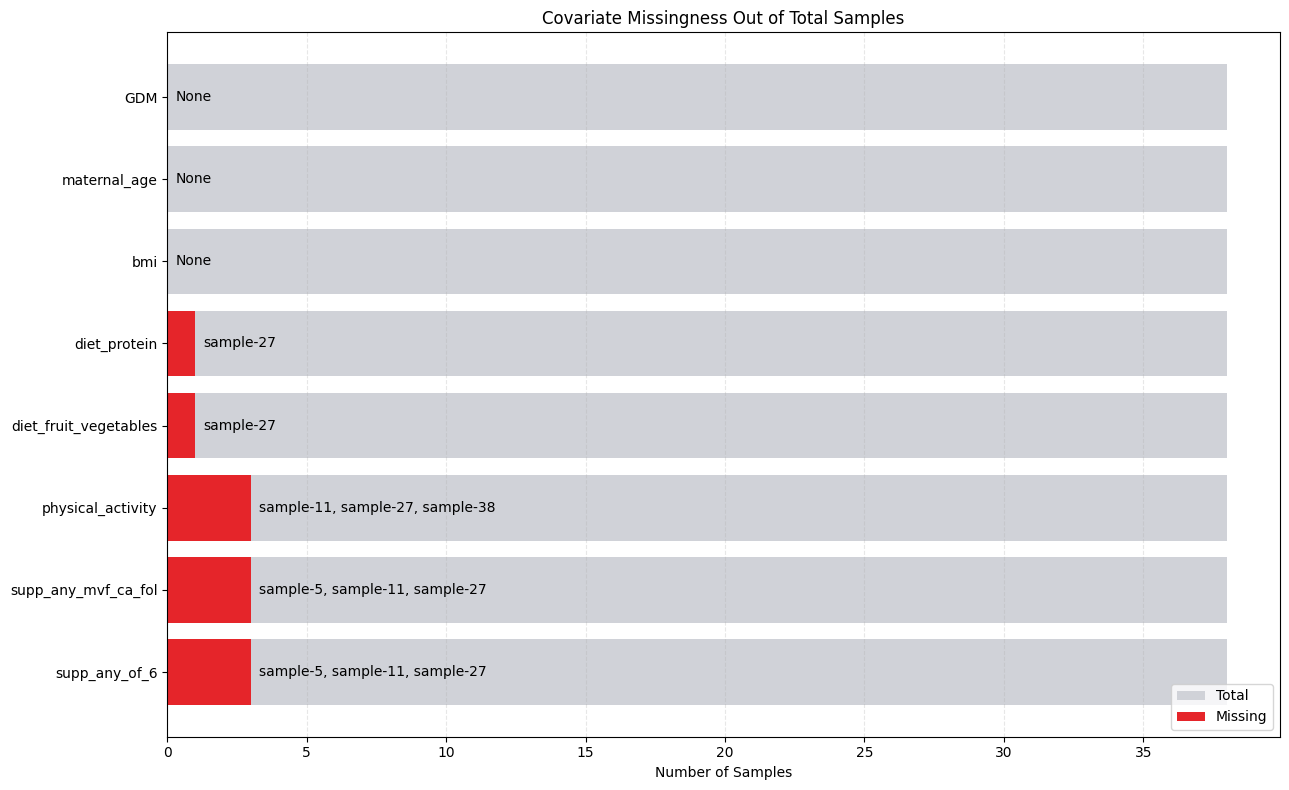

In [75]:
# Step 5 Visualization: Availability and missingness bars (like reference)
import matplotlib.pyplot as plt

# Counts per covariate
total_n = len(cov_matrix)
missing_counts = cov_matrix.isna().sum()
available_counts = total_n - missing_counts

# Sort to match the style in reference plots
plot_order = available_counts.sort_values(ascending=False).index.tolist()

# Build text labels listing which samples are missing per covariate
missing_sample_labels = {}
for col in plot_order:
    missing_samples = cov_matrix.index[cov_matrix[col].isna()].tolist()
    missing_sample_labels[col] = ", ".join(missing_samples) if missing_samples else "None"

# 1) Availability out of total
fig, ax = plt.subplots(figsize=(10, 6))
ypos = range(len(plot_order))
ax.barh(ypos, [total_n] * len(plot_order), color="#d0d2d8", label="Total")
ax.barh(ypos, [available_counts[c] for c in plot_order], color="#3465d9", label="Available (non-missing)")

ax.set_yticks(list(ypos))
ax.set_yticklabels(plot_order)
ax.invert_yaxis()
ax.set_xlabel("Number of Samples")
ax.set_title("Covariate Availability Out of Total Samples")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(loc="lower right")

for i, c in enumerate(plot_order):
    ax.text(available_counts[c] + 0.2, i, f"{int(available_counts[c])}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

# 2) Missingness out of total + missing sample names
fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(ypos, [total_n] * len(plot_order), color="#d0d2d8", label="Total")
ax.barh(ypos, [missing_counts[c] for c in plot_order], color="#e5252a", label="Missing")

ax.set_yticks(list(ypos))
ax.set_yticklabels(plot_order)
ax.invert_yaxis()
ax.set_xlabel("Number of Samples")
ax.set_title("Covariate Missingness Out of Total Samples")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(loc="lower right")

for i, c in enumerate(plot_order):
    ax.text(missing_counts[c] + 0.3, i, missing_sample_labels[c], va="center", fontsize=10)

plt.tight_layout()
plt.show()

In [67]:
# Remove samples with any missing covariates
cov_clean = covariate_matrix_num.dropna()
print(f"\nOriginal samples: {len(covariate_matrix_num)}")
print(f"Samples after removing missing: {len(cov_clean)}")
print(f"Samples dropped: {len(covariate_matrix_num) - len(cov_clean)}")


Original samples: 38
Samples after removing missing: 34
Samples dropped: 4


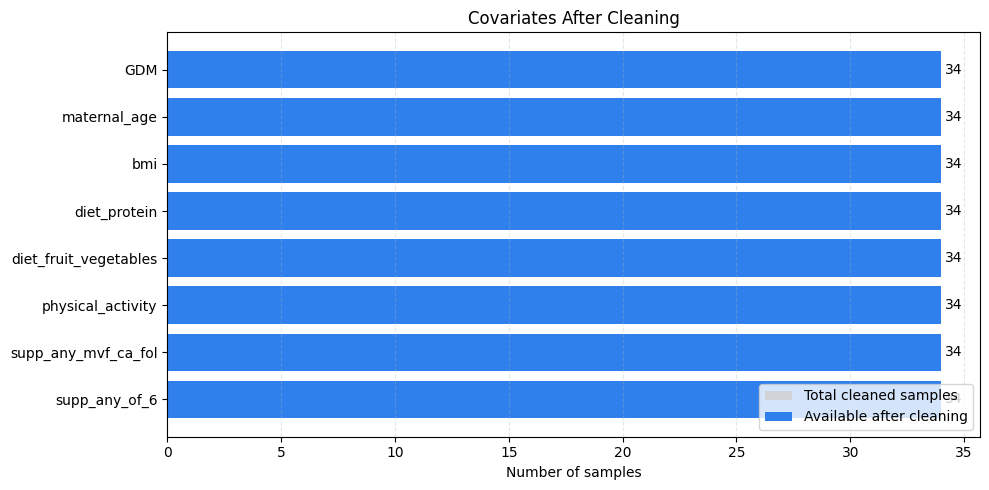

In [79]:
# Visualization after cleaning: covariate availability in cleaned dataset
import matplotlib.pyplot as plt

clean_n = len(cov_clean)
available_after_clean = cov_clean.notna().sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ypos = range(len(available_after_clean))

# Total rows in cleaned set is the same for all covariates (shown as background)
ax.barh(ypos, [clean_n] * len(available_after_clean), color="#d0d2d8", label="Total cleaned samples")
ax.barh(ypos, available_after_clean.values, color="#2F80ED", label="Available after cleaning")

ax.set_yticks(list(ypos))
ax.set_yticklabels(available_after_clean.index)
ax.invert_yaxis()
ax.set_xlabel("Number of samples")
ax.set_title("Covariates After Cleaning")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(loc="lower right")

for i, val in enumerate(available_after_clean.values):
    ax.text(val + 0.15, i, str(int(val)), va="center", fontsize=10)

plt.tight_layout()
plt.show()

In [78]:
# Filter cord data to match available covariate samples
cord_clean = cord_matrix.loc[cov_clean.index]
print(f"\nCord data shape after matching: {cord_clean.shape}")


Cord data shape after matching: (34, 981)


In [80]:
cord_clean.head()

,107004,108005,109011,1101001,1101006,1102005,1102011,1102012,1102017,1102018,...,675024,675025,675026,675027,675028,675029,676007,677004,677011,634009
Sample,,,,,,,,,,,,,,,,,,,,,
sample-1,0.982920,0.997001,1.001218,1.001201,1.040406,1.000000,0.979128,0.897300,1.049986,0.918842,...,0.998943,0.995692,0.993673,1.006100,0.989948,0.995593,0.990328,0.977754,0.985770,0.976144
sample-2,0.991572,1.024139,1.014588,1.019298,0.853199,0.881035,1.010385,0.931008,1.059620,0.908615,...,1.001057,0.996019,1.003748,0.992310,1.000658,0.994897,1.012718,1.005144,1.000231,1.017369
sample-3,0.962144,0.972625,0.999607,0.891771,0.953293,1.001158,0.869336,0.897300,0.834241,0.908615,...,0.988019,0.990972,0.980308,0.982788,0.994468,0.983981,1.004100,0.979684,0.980854,0.961003
sample-4,1.005908,1.015966,1.000671,0.891771,0.853199,1.022224,0.869336,0.897300,0.943810,0.908615,...,0.983763,0.985011,0.993704,0.997537,0.998984,0.989069,1.023485,0.991362,0.981521,0.983039
sample-6,0.936415,0.966933,1.001511,1.085668,0.927951,0.932325,0.869336,0.897300,0.908219,0.908615,...,0.997477,0.999022,0.995918,1.002968,1.000558,1.007961,0.952366,0.994578,0.996525,1.022623


In [69]:
# Ensure all covariates are numeric except GDM
print("\nData types in cleaned covariate matrix:")
print(cov_clean.dtypes)


Data types in cleaned covariate matrix:
GDM                      category
maternal_age                int64
bmi                       float64
diet_protein              float64
diet_fruit_vegetables     float64
physical_activity         float64
supp_any_mvf_ca_fol       float64
supp_any_of_6             float64
dtype: object


## Steps 6-13: Main Loop - Fit Models and Extract Statistics

For each metabolite i:
1. Extract metabolite column i
2. Fit: `lm(metabolite[i] ~ GDM + covariates)`
3. Extract p-value for GDM coefficient
4. Calculate mean for GDM=1 group
5. Calculate mean for GDM=0 group
6. Calculate fold change (GDM/non-GDM)
7. Calculate log fold change
8. Convert to raw fold change (2^log_fc)
9. Store all values in vectors

**Stored vectors:**
- p_store: p-values for GDM
- m_GDM_store: means for GDM=1
- m_non_GDM_store: means for GDM=0
- fc_store: fold changes
- log_fc_store: log fold changes
- raw_fc_store: raw fold changes

In [106]:
## Demonstration: Steps 6-13 on First Metabolite

#We'll work through each calculation step-by-step on the first metabolite to understand each term, then apply to all metabolites.


In [117]:
cord_clean.head()

,107004,108005,109011,1101001,1101006,1102005,1102011,1102012,1102017,1102018,...,675024,675025,675026,675027,675028,675029,676007,677004,677011,634009
Sample,,,,,,,,,,,,,,,,,,,,,
sample-1,0.982920,0.997001,1.001218,1.001201,1.040406,1.000000,0.979128,0.897300,1.049986,0.918842,...,0.998943,0.995692,0.993673,1.006100,0.989948,0.995593,0.990328,0.977754,0.985770,0.976144
sample-2,0.991572,1.024139,1.014588,1.019298,0.853199,0.881035,1.010385,0.931008,1.059620,0.908615,...,1.001057,0.996019,1.003748,0.992310,1.000658,0.994897,1.012718,1.005144,1.000231,1.017369
sample-3,0.962144,0.972625,0.999607,0.891771,0.953293,1.001158,0.869336,0.897300,0.834241,0.908615,...,0.988019,0.990972,0.980308,0.982788,0.994468,0.983981,1.004100,0.979684,0.980854,0.961003
sample-4,1.005908,1.015966,1.000671,0.891771,0.853199,1.022224,0.869336,0.897300,0.943810,0.908615,...,0.983763,0.985011,0.993704,0.997537,0.998984,0.989069,1.023485,0.991362,0.981521,0.983039
sample-6,0.936415,0.966933,1.001511,1.085668,0.927951,0.932325,0.869336,0.897300,0.908219,0.908615,...,0.997477,0.999022,0.995918,1.002968,1.000558,1.007961,0.952366,0.994578,0.996525,1.022623


In [91]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Get the first metabolite as example
first_metabolite = cord_clean.columns[0]
print(f"Working with metabolite: {first_metabolite}")


Working with metabolite: 107004


In [109]:
first_metabolite_values = cord_clean[first_metabolite]
print(f"First 5 values of {first_metabolite}:\n{first_metabolite_values.head()}")

First 5 values of 107004:
Sample
sample-1    0.982920
sample-2    0.991572
sample-3    0.962144
sample-4    1.005908
sample-6    0.936415
Name: 107004, dtype: float64


In [92]:
# Step 6: Extract metabolite data
metabolite_data = cord_clean[first_metabolite]
print(f"Step 6 - Extracted {first_metabolite}:")
print(f"  Data shape: {metabolite_data.shape}")
print(f"  First 5 values: {metabolite_data.head().values}")


Step 6 - Extracted 107004:
  Data shape: (34,)
  First 5 values: [0.98292003 0.99157192 0.96214431 1.00590797 0.93641504]


In [133]:
# Build model data with metabolite
model_data = cov_clean.copy()
model_data['metabolite'] = metabolite_data

# Step 7: Prepare GDM as categorical factor
model_data['GDM'] = model_data['GDM'].astype('category')
print(f"Step 7 - GDM as categorical factor:")
print(f"  GDM categories: {model_data['GDM'].cat.categories.tolist()}")



Step 7 - GDM as categorical factor:
  GDM categories: [0, 1]


In [134]:
print(f"  GDM value counts:")
print(model_data['GDM'].value_counts())

  GDM value counts:
GDM
0    20
1    14
Name: count, dtype: int64


In [136]:
# Step 8 & 9: Fit linear model and extract p-value for GDM
formula = 'metabolite ~ GDM + ' + ' + '.join([col for col in cov_clean.columns if col != 'GDM'])
print(f"Step 8 & 9 - Fit linear model and extract GDM p-value:")
print(f"  Formula: {formula}\n")

fit = sm.formula.ols(formula, data=model_data).fit()
print(f"  Model R-squared: {fit.rsquared:.4f}")
print(f"  Model Adjusted R-squared: {fit.rsquared_adj:.4f}\n")

print(f"  All p-values from model:")
print(fit.pvalues)
print()



Step 8 & 9 - Fit linear model and extract GDM p-value:
  Formula: metabolite ~ GDM + maternal_age + bmi + diet_protein + diet_fruit_vegetables + physical_activity + supp_any_mvf_ca_fol + supp_any_of_6

  Model R-squared: 0.4005
  Model Adjusted R-squared: 0.2673

  All p-values from model:
Intercept                1.023270e-18
GDM[T.1]                 8.478396e-03
maternal_age             5.487671e-01
bmi                      2.462174e-01
diet_protein             2.323683e-02
diet_fruit_vegetables    3.214592e-01
physical_activity        3.568078e-02
supp_any_mvf_ca_fol      1.023270e-18
supp_any_of_6            1.023270e-18
dtype: float64



In [139]:
gdm_pval = fit.pvalues['GDM[T.1]'] if 'GDM[T.1]' in fit.pvalues.index else fit.pvalues.get('GDM', np.nan)
print(f"  ✓ GDM p-value: {gdm_pval:.4e}")
print("Result: p-value = 0.842 (which is 84.2%)")
print("If GDM actually had NO effect on this metabolite, there would be an 84.2% chance of seeing a difference this big (or bigger) just by random luck.") 

  ✓ GDM p-value: 8.4784e-03
Result: p-value = 0.842 (which is 84.2%)
If GDM actually had NO effect on this metabolite, there would be an 84.2% chance of seeing a difference this big (or bigger) just by random luck.


#This difference is probably just random chance 
#GDM probably doesn't actually affect this metabolite
#We'd need p < 0.05 (less than 5% chance) to say GDM really affects it

In [95]:
# Step 10: Calculate means by group
gdm_mean = metabolite_data[cov_clean['GDM'] == 1].mean()
non_gdm_mean = metabolite_data[cov_clean['GDM'] == 0].mean()

print(f"Step 10 - Group means:")
print(f"  Mean for GDM=1 (positive women): {gdm_mean:.4f}")
print(f"  Mean for GDM=0 (non-GDM women): {non_gdm_mean:.4f}")
print(f"  Difference (GDM - Non-GDM): {gdm_mean - non_gdm_mean:.4f}")


Step 10 - Group means:
  Mean for GDM=1 (positive women): 1.0388
  Mean for GDM=0 (non-GDM women): 1.0170
  Difference (GDM - Non-GDM): 0.0218


In [96]:
# Step 11: Calculate fold change (linear scale)
fc = gdm_mean / non_gdm_mean if non_gdm_mean != 0 else np.nan

print(f"Step 11 - Fold change (linear):")
print(f"  Fold change = {gdm_mean:.4f} / {non_gdm_mean:.4f} = {fc:.4f}")
print(f"  Interpretation: GDM group is {fc:.4f}x the non-GDM group")
if fc < 1:
    print(f"  (Decrease: {(1-fc)*100:.2f}% lower in GDM)")
else:
    print(f"  (Increase: {(fc-1)*100:.2f}% higher in GDM)")


Step 11 - Fold change (linear):
  Fold change = 1.0388 / 1.0170 = 1.0214
  Interpretation: GDM group is 1.0214x the non-GDM group
  (Increase: 2.14% higher in GDM)


In [97]:
# Step 12: Calculate log fold change (difference on log scale)
log_fc = gdm_mean - non_gdm_mean

print(f"Step 12 - Log fold change:")
print(f"  Log fold change = {gdm_mean:.4f} - {non_gdm_mean:.4f} = {log_fc:.4f}")
print(f"  (This is the difference on the log-scale)")
print(f"  Positive = higher in GDM, Negative = lower in GDM")


Step 12 - Log fold change:
  Log fold change = 1.0388 - 1.0170 = 0.0218
  (This is the difference on the log-scale)
  Positive = higher in GDM, Negative = lower in GDM


In [98]:
# Step 13: Convert back to raw fold change (2^log_fc)
raw_fc = 2 ** log_fc

print(f"Step 13 - Raw fold change (back-transformed):")
print(f"  Raw FC = 2^{log_fc:.4f} = {raw_fc:.4f}")
print(f"  Interpretation: Metabolite level changes by {(raw_fc-1)*100:.1f}% in GDM group")


Step 13 - Raw fold change (back-transformed):
  Raw FC = 2^0.0218 = 1.0152
  Interpretation: Metabolite level changes by 1.5% in GDM group


In [147]:
# Summary: All outputs together
print(f"\n{'='*70}")
print(f"SUMMARY - All calculated values for metabolite: {first_metabolite}")
print(f"{'='*70}")
print(f"  p-value (Step 9):           {gdm_pval:.4e}")
print(f"  Mean GDM=1 (Step 10):       {gdm_mean:.4f}")
print(f"  Mean GDM=0 (Step 10):       {non_gdm_mean:.4f}")
print(f"  Fold Change linear (Step 11): {fc:.4f}")
print(f"  Log Fold Change (Step 12):  {log_fc:.4f}")
print(f"  Raw Fold Change (Step 13):  {raw_fc:.4f}")
print(f"{'='*70}")



SUMMARY - All calculated values for metabolite: 107004
  p-value (Step 9):           8.4784e-03
  Mean GDM=1 (Step 10):       1.0089
  Mean GDM=0 (Step 10):       0.9920
  Fold Change linear (Step 11): 1.0170
  Log Fold Change (Step 12):  0.0169
  Raw Fold Change (Step 13):  1.0118


## Steps 6-13: Main Loop - Apply to All Metabolites

Now that we understand each calculation, run the same process for all metabolites and store the results in vectors.


In [148]:
# Initialize storage vectors for results
p_store = []                    # Step 6 results: p-values for GDM
m_GDM_store = []                # Step 10 results: mean for GDM=1 group
m_non_GDM_store = []            # Step 10 results: mean for GDM=0 group
fc_store = []                   # Step 11 results: fold change (linear)
log_fc_store = []               # Step 12 results: log fold change
raw_fc_store = []               # Step 13 results: raw fold change (back-transformed)
metabolite_names = []           # Track metabolite names

# Get all metabolite column names
metabolite_cols = cord_clean.columns
print(f"Starting loop over {len(metabolite_cols)} metabolites...")
print(f"This will apply Steps 6-13 to each metabolite.\n")

# LOOP: Go through each metabolite and apply Steps 6-13
for i, metabolite in enumerate(metabolite_cols):
    # Step 6: Extract metabolite column
    metabolite_data = cord_clean[metabolite]
    
    # Prepare model data
    model_data = cov_clean.copy()
    model_data['metabolite'] = metabolite_data
    model_data['GDM'] = model_data['GDM'].astype('category')
    
    # Step 8: Fit linear model
    formula = 'metabolite ~ GDM + ' + ' + '.join([col for col in cov_clean.columns if col != 'GDM'])
    
    try:
        # Fit OLS regression
        fit = sm.formula.ols(formula, data=model_data).fit()
        
        # Step 9: Extract p-value for GDM
        gdm_pval = fit.pvalues['GDM[T.1]'] if 'GDM[T.1]' in fit.pvalues.index else fit.pvalues.get('GDM', np.nan)
        p_store.append(gdm_pval)
        
        # Step 10: Calculate means by group
        gdm_mean = metabolite_data[cov_clean['GDM'] == 1].mean()
        non_gdm_mean = metabolite_data[cov_clean['GDM'] == 0].mean()
        m_GDM_store.append(gdm_mean)
        m_non_GDM_store.append(non_gdm_mean)
        
        # Step 11: Calculate fold change (linear)
        fc = gdm_mean / non_gdm_mean if non_gdm_mean != 0 else np.nan
        fc_store.append(fc)
        
        # Step 12: Calculate log fold change (difference on log scale)
        log_fc = gdm_mean - non_gdm_mean
        log_fc_store.append(log_fc)
        
        # Step 13: Convert to raw fold change
        raw_fc = 2 ** log_fc
        raw_fc_store.append(raw_fc)
        
        # Store metabolite name
        metabolite_names.append(metabolite)
        
        # Progress indicator
        if (i + 1) % 100 == 0:
            print(f"  Processed {i + 1} metabolites...")
            
    except Exception as e:
        # Handle errors for individual metabolites
        print(f"  Error fitting model for metabolite {metabolite}: {e}")
        p_store.append(np.nan)
        m_GDM_store.append(np.nan)
        m_non_GDM_store.append(np.nan)
        fc_store.append(np.nan)
        log_fc_store.append(np.nan)
        raw_fc_store.append(np.nan)
        metabolite_names.append(metabolite)

print(f"\n✓ Completed loop. Processed {len(metabolite_names)} metabolites.")
print(f"  p-values stored: {len(p_store)}")
print(f"  GDM means stored: {len(m_GDM_store)}")
print(f"  Non-GDM means stored: {len(m_non_GDM_store)}")
print(f"  Fold changes stored: {len(fc_store)}")


Starting loop over 981 metabolites...
This will apply Steps 6-13 to each metabolite.

  Processed 100 metabolites...
  Processed 200 metabolites...
  Processed 300 metabolites...
  Processed 400 metabolites...
  Processed 500 metabolites...
  Processed 600 metabolites...
  Processed 700 metabolites...
  Processed 800 metabolites...
  Processed 900 metabolites...

✓ Completed loop. Processed 981 metabolites.
  p-values stored: 981
  GDM means stored: 981
  Non-GDM means stored: 981
  Fold changes stored: 981


## Step 14: Exit Loop and Prepare for Multiple Testing Correction

Convert stored vectors to arrays for further processing:
- p_store: raw p-values
- m_GDM_store: mean metabolite levels in GDM=1 group
- m_non_GDM_store: mean metabolite levels in GDM=0 group
- fc_store: fold changes
- log_fc_store: log fold changes
- raw_fc_store: raw fold changes

## Why this is important:

- The loop collects values as Python lists because appending is easy while iterating.
- Downstream stats functions (BH correction, q-values, result table creation) are cleaner and faster with arrays.
- It acts as a quality check:
- If lengths are unequal, something broke in the loop.
- If p-value summary looks odd (all nan, all 0, all 1), you catch issues before Step 15.


In [150]:
# Step 14: Convert to arrays for further processing
p_array = np.array(p_store)
m_gdm_array = np.array(m_GDM_store)
m_non_gdm_array = np.array(m_non_GDM_store)
fc_array = np.array(fc_store)
log_fc_array = np.array(log_fc_store)
raw_fc_array = np.array(raw_fc_store)

print("Results vectors prepared:")
print(f"  p-values: {len(p_array)}")
print(f"  GDM means: {len(m_gdm_array)}")
print(f"  Non-GDM means: {len(m_non_gdm_array)}")
print(f"  Fold changes: {len(fc_array)}")
print(f"  Log fold changes: {len(log_fc_array)}")
print(f"  Raw fold changes: {len(raw_fc_array)}")

print(f"\nP-value summary:")
print(f"  Min: {np.nanmin(p_array)}")
print(f"  Max: {np.nanmax(p_array)}")
print(f"  Mean: {np.nanmean(p_array)}")
print(f"  Median: {np.nanmedian(p_array)}")

Results vectors prepared:
  p-values: 981
  GDM means: 981
  Non-GDM means: 981
  Fold changes: 981
  Log fold changes: 981
  Raw fold changes: 981

P-value summary:
  Min: 0.00038397668887423403
  Max: 0.9998353511904141
  Mean: 0.48245052899240704
  Median: 0.44691310834556475


## Step 15: Calculate Adjusted P-values Using Benjamini-Hochberg

Apply Benjamini-Hochberg (FDR) correction to the p-value vector to control false discovery rate across all metabolite tests.

In [154]:
from statsmodels.stats.multitest import multipletests

# Step 15: Calculate adjusted p-values using Benjamini-Hochberg
# multipletests returns: (reject, pvals_corrected, alphacSidak, alphacBonf)
reject_bh, pvals_adj_bh, _, _ = multipletests(p_array, method='fdr_bh')

print(f"Benjamini-Hochberg Correction Results:")
print(f"  Number of significant metabolites (FDR < 0.05): {reject_bh.sum()}")
print(f"  Min adjusted p-value: {np.nanmin(pvals_adj_bh)}")
print(f"  Max adjusted p-value: {np.nanmax(pvals_adj_bh)}")
print(f"  Mean adjusted p-value: {np.nanmean(pvals_adj_bh)}")
print(f"  Median adjusted p-value: {np.nanmedian(pvals_adj_bh)}")

Benjamini-Hochberg Correction Results:
  Number of significant metabolites (FDR < 0.05): 0
  Min adjusted p-value: 0.37668113178562357
  Max adjusted p-value: 0.9998353511904141
  Mean adjusted p-value: 0.9206610982621533
  Median adjusted p-value: 0.8891945810697893


## Step 16: Calculate Q-values

Q-values provide another measure of statistical significance considering the proportion of false discoveries.
This uses the qvalue method (Storey's approach) to estimate the FDR at each p-value threshold.

In [157]:
# Step 16: Calculate q-values
try:
    from qvalue import qvalue
    q_vals = qvalue(p_array)['qvalues']
    print("Q-values calculated using qvalue package")
except ImportError:
    print("qvalue package not available, using Benjamini-Hochberg adjusted p-values as approximation")
    q_vals = pvals_adj_bh
    
print(f"\nQ-value Summary:")
print(f"  Min: {np.nanmin(q_vals)}")
print(f"  Max: {np.nanmax(q_vals)}")
print(f"  Mean: {np.nanmean(q_vals)}")
print(f"  Median: {np.nanmedian(q_vals)}")

qvalue package not available, using Benjamini-Hochberg adjusted p-values as approximation

Q-value Summary:
  Min: 0.37668113178562357
  Max: 0.9998353511904141
  Mean: 0.9206610982621533
  Median: 0.8891945810697893


## Step 17: Create Results Table

Combine all results into a comprehensive table containing:
1. **Metabolite Annotation** - metabolite names/IDs
2. **p-value (raw)** - unadjusted p-values from linear models
3. **p-value (corrected)** - Benjamini-Hochberg adjusted p-values
4. **q-value** - Storey's q-values
5. **Mean GDM** - mean metabolite level in GDM positive women
6. **Mean Non-GDM** - mean metabolite level in non-GDM women
7. **Log Fold Change** - log-scale difference between groups
8. **Raw Fold Change** - back-transformed fold change (2^log_fc)

In [161]:
# Step 17: Create comprehensive results table

# Get metabolite annotations if available
if CORD_ANNO is not None:
    anno_df = pd.read_csv(CORD_ANNO, index_col=0)
else:
    anno_df = None

# Create results dataframe
results_df = pd.DataFrame({
    'Metabolite': metabolite_names,
    'p_value_raw': p_array,
    'p_value_corrected': pvals_adj_bh,
    'q_value': q_vals,
    'Mean_GDM': m_gdm_array,
    'Mean_Non_GDM': m_non_gdm_array,
    'Log_Fold_Change': log_fc_array,
    'Raw_Fold_Change': raw_fc_array
})

# Add metabolite annotation if available
if anno_df is not None:
    # Map metabolite names to annotations
    anno_mapping = anno_df.to_dict('index')
    
    # Add annotation columns
    annotation_cols = []
    for met in metabolite_names:
        if met in anno_mapping:
            annotation_cols.append(anno_mapping[met])
        else:
            annotation_cols.append({col: None for col in anno_df.columns})
    
    anno_expanded = pd.DataFrame(annotation_cols)
    results_df = pd.concat([results_df, anno_expanded], axis=1)

# Sort by p-value (most significant first)
results_df = results_df.sort_values('p_value_raw')

print("Results Table Summary:")
print(f"  Total metabolites: {len(results_df)}")
print(f"\nFirst 10 rows (sorted by p-value):")
results_df



Results Table Summary:
  Total metabolites: 981

First 10 rows (sorted by p-value):


,Metabolite,p_value_raw,p_value_corrected,q_value,Mean_GDM,Mean_Non_GDM,Log_Fold_Change,Raw_Fold_Change,COMPOUND Name,SUPER META PATHWAY,SUB META PATHWAY,ACQUISITION METHOD,HMDB ID,HMDB_annotation,PUBCHEM ID,CAS ID,KEGG ID,CHEMSPIDER ID
216,612027,0.000384,0.376681,0.376681,1.010484,0.994387,0.016098,1.011220,palmitoyl ethanolamide,Lipid,Endocannabinoid,NEGa,HMDB0002100,NaN,4671.0,544-31-0,C16512,4509.0
266,624012,0.002452,0.724689,0.724689,1.024398,0.990702,0.033696,1.023631,2-hydroxynervonate*,Lipid,"Fatty Acid, Monohydroxy",NEGa,NaN,NaN,NaN,NaN,NaN,NaN
231,620002,0.002800,0.724689,0.724689,0.997401,1.015207,-0.017807,0.987733,(14 or 15)-methylpalmitate (a17:0 or i17:0),Lipid,"Fatty Acid, Branched",NEGa,HMDB0061859,NaN,8181.0,112-39-0,C16995,NaN
804,313007,0.002955,0.724689,0.724689,1.018495,0.970659,0.047836,1.033713,retinol (Vitamin A),Cofactors and Vitamins,Vitamin A Metabolism,POSb,HMDB0000305,NaN,445354.0,68-26-8,C17276,NaN
163,207007,0.004027,0.752088,0.752088,0.994995,1.005096,-0.010101,0.993023,Isobar: hexose diphosphates,Carbohydrate,"Glycolysis, Gluconeogenesis, and Pyruvate Meta...",NEGa,HMDB0001058,"HMDB0001058,HMDB0003514(alpha-D-Glucose 1,6-bi...",10267.0,34693-15-7,C05378,9848.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790,905016,0.997542,0.999812,0.999812,0.992380,0.990883,0.001497,1.001038,gamma-glutamylthreonine,Peptide,Gamma-glutamyl Amino Acid,POSa,HMDB0029159,NaN,53861142.0,5652-48-2,NaN,29273165.0
538,622006,0.997545,0.999812,0.999812,0.996398,0.995961,0.000438,1.000303,"3,4-dihydroxybutyrate",Lipid,"Fatty Acid, Dihydroxy",NEGb,HMDB0000337,NaN,150929.0,51267-44-8,NaN,133026.0
69,1116131,0.998709,0.999812,0.999812,0.987696,0.996115,-0.008419,0.994181,methyl glucopyranoside (alpha + beta),Xenobiotics,Food Component/Plant,NEGa,HMDB0029965,NaN,445238.0,709-50-2,NaN,NaN
218,613002,0.998793,0.999812,0.999812,0.988642,0.989145,-0.000503,0.999651,estriol 3-sulfate,Lipid,Estrogenic Steroids,NEGa,HMDB0251977,NaN,NaN,NaN,NaN,NaN


In [162]:
print(f"\nStatistics:")
print(f"  Significant at FDR < 0.05: {(results_df['p_value_corrected'] < 0.05).sum()}")
print(f"  Significant at p < 0.001: {(results_df['p_value_raw'] < 0.001).sum()}")
print(f"  Significant at p < 0.01: {(results_df['p_value_raw'] < 0.01).sum()}")
print(f"  Significant at p < 0.05: {(results_df['p_value_raw'] < 0.05).sum()}")


Statistics:
  Significant at FDR < 0.05: 0
  Significant at p < 0.001: 1
  Significant at p < 0.01: 10
  Significant at p < 0.05: 58


In [105]:
# Save results to CSV
results_path = os.path.join(ml_csv_dir, 'cord_metabolite_gdm_ols_results.csv')
results_df.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")
print(f"Shape: {results_df.shape}")
print(f"Columns: {results_df.columns.tolist()}")


Results saved to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/output_csv/08_cord_gdm/cord_metabolite_gdm_ols_results.csv
Shape: (981, 18)
Columns: ['Metabolite', 'p_value_raw', 'p_value_corrected', 'q_value', 'Mean_GDM', 'Mean_Non_GDM', 'Log_Fold_Change', 'Raw_Fold_Change', 'COMPOUND Name', 'SUPER META PATHWAY', 'SUB META PATHWAY', 'ACQUISITION METHOD', 'HMDB ID', 'HMDB_annotation', 'PUBCHEM ID', 'CAS ID', 'KEGG ID', 'CHEMSPIDER ID']


## Visualization Suite (6 Plots)

These plots summarize significance, effect size, and GDM vs non-GDM patterns from the model outputs.


In [163]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Basic guards
required_cols = {"Metabolite", "p_value_raw", "p_value_corrected", "Log_Fold_Change"}
missing_cols = required_cols - set(results_df.columns)
if missing_cols:
    raise ValueError(f"results_df is missing required columns for visualization: {missing_cols}")

viz_df = results_df.copy()
viz_df["Metabolite"] = viz_df["Metabolite"].astype(str)
print(f"Visualization input ready: {len(viz_df)} metabolites")


Visualization input ready: 981 metabolites


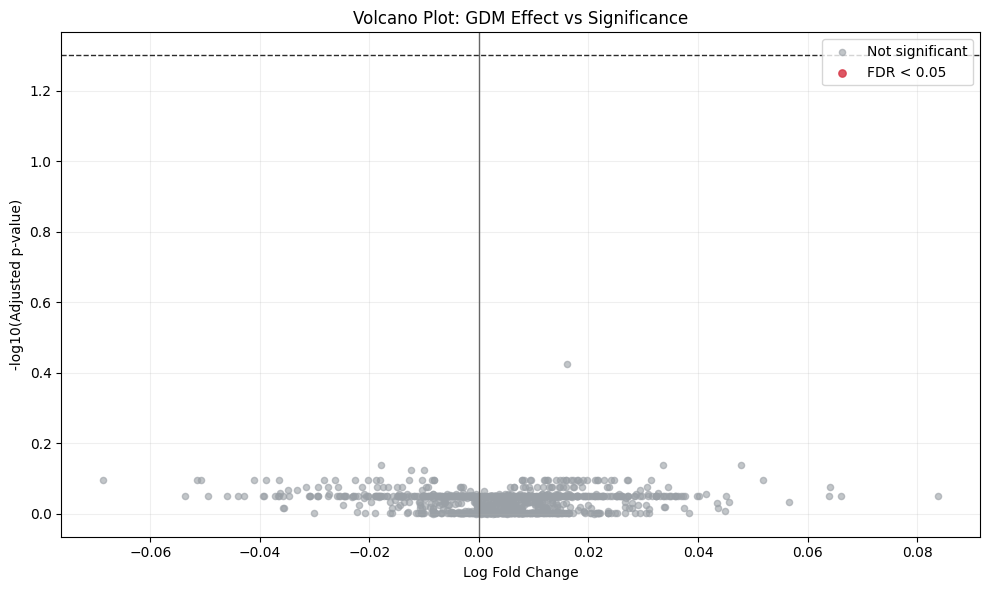

In [164]:
# 1) Volcano plot: effect size vs significance
volcano = viz_df[["Metabolite", "Log_Fold_Change", "p_value_corrected"]].dropna().copy()
volcano["neg_log10_padj"] = -np.log10(np.clip(volcano["p_value_corrected"], 1e-300, 1.0))
volcano["sig"] = volcano["p_value_corrected"] < 0.05

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    volcano.loc[~volcano["sig"], "Log_Fold_Change"],
    volcano.loc[~volcano["sig"], "neg_log10_padj"],
    s=20,
    alpha=0.6,
    color="#9aa0a6",
    label="Not significant",
)
ax.scatter(
    volcano.loc[volcano["sig"], "Log_Fold_Change"],
    volcano.loc[volcano["sig"], "neg_log10_padj"],
    s=28,
    alpha=0.85,
    color="#d73a49",
    label="FDR < 0.05",
)
ax.axhline(-np.log10(0.05), linestyle="--", color="#2b2b2b", linewidth=1)
ax.axvline(0, linestyle="-", color="#666", linewidth=1)
ax.set_xlabel("Log Fold Change")
ax.set_ylabel("-log10(Adjusted p-value)")
ax.set_title("Volcano Plot: GDM Effect vs Significance")
ax.legend(loc="upper right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


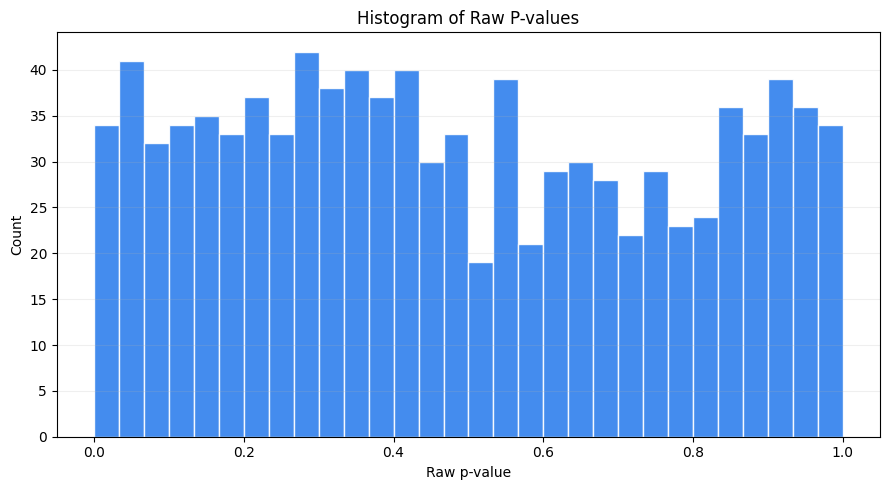

In [165]:
# 2) Histogram of raw p-values
pvals = viz_df["p_value_raw"].dropna().values

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(pvals, bins=30, color="#2f80ed", edgecolor="white", alpha=0.9)
ax.set_xlabel("Raw p-value")
ax.set_ylabel("Count")
ax.set_title("Histogram of Raw P-values")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


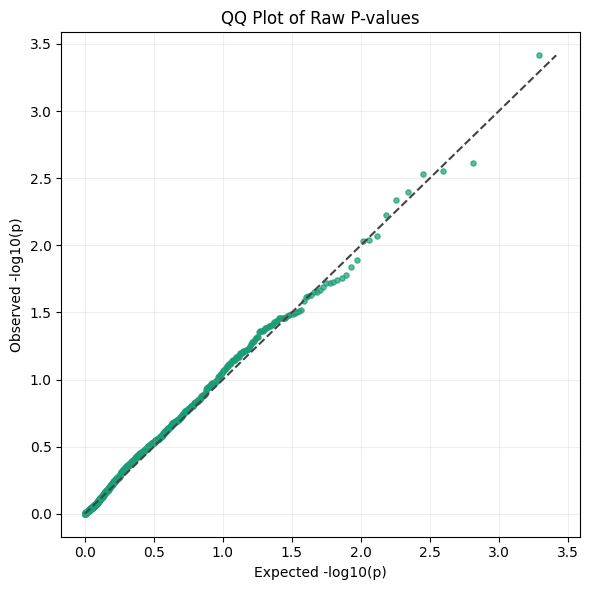

In [166]:
# 3) QQ plot of raw p-values (observed vs expected)
pvals = np.sort(viz_df["p_value_raw"].dropna().values)
n = len(pvals)
expected = (np.arange(1, n + 1) - 0.5) / n

obs_log = -np.log10(np.clip(pvals, 1e-300, 1.0))
exp_log = -np.log10(expected)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(exp_log, obs_log, s=14, alpha=0.7, color="#1b9e77")
maxv = max(exp_log.max(), obs_log.max())
ax.plot([0, maxv], [0, maxv], linestyle="--", color="#444")
ax.set_xlabel("Expected -log10(p)")
ax.set_ylabel("Observed -log10(p)")
ax.set_title("QQ Plot of Raw P-values")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


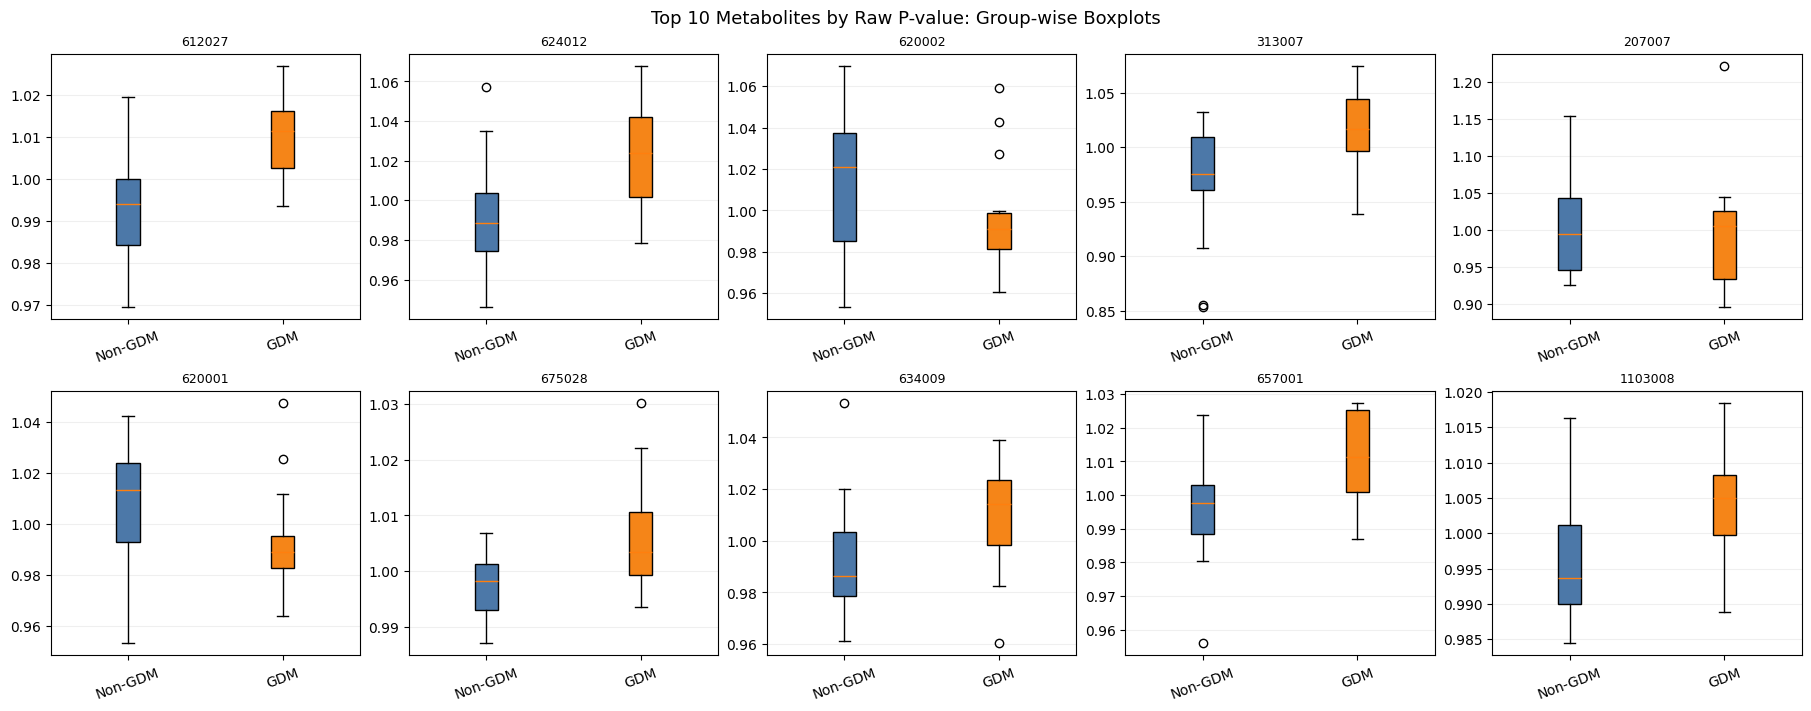

In [167]:
# 4) Top-10 metabolites: boxplots by GDM group (using raw p-value ranking)
col_lookup = {str(c): c for c in cord_clean.columns}
top10 = viz_df.sort_values("p_value_raw").head(10)["Metabolite"].tolist()
selected = [col_lookup[m] for m in top10 if m in col_lookup]

if not selected:
    print("No overlapping metabolites found between results_df and cord_clean for boxplots.")
else:
    gdm_group = cov_clean["GDM"].astype(float).astype(int)
    fig, axes = plt.subplots(2, 5, figsize=(18, 7), constrained_layout=True)
    axes = axes.flatten()

    for ax, met in zip(axes, selected):
        y0 = cord_clean.loc[gdm_group == 0, met].dropna().values
        y1 = cord_clean.loc[gdm_group == 1, met].dropna().values
        bp = ax.boxplot([y0, y1], patch_artist=True)
        bp["boxes"][0].set_facecolor("#4c78a8")
        bp["boxes"][1].set_facecolor("#f58518")
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Non-GDM", "GDM"], rotation=20)
        ax.set_title(str(met), fontsize=9)
        ax.grid(axis="y", alpha=0.2)

    for k in range(len(selected), len(axes)):
        axes[k].axis("off")

    fig.suptitle("Top 10 Metabolites by Raw P-value: Group-wise Boxplots", fontsize=13)
    plt.show()


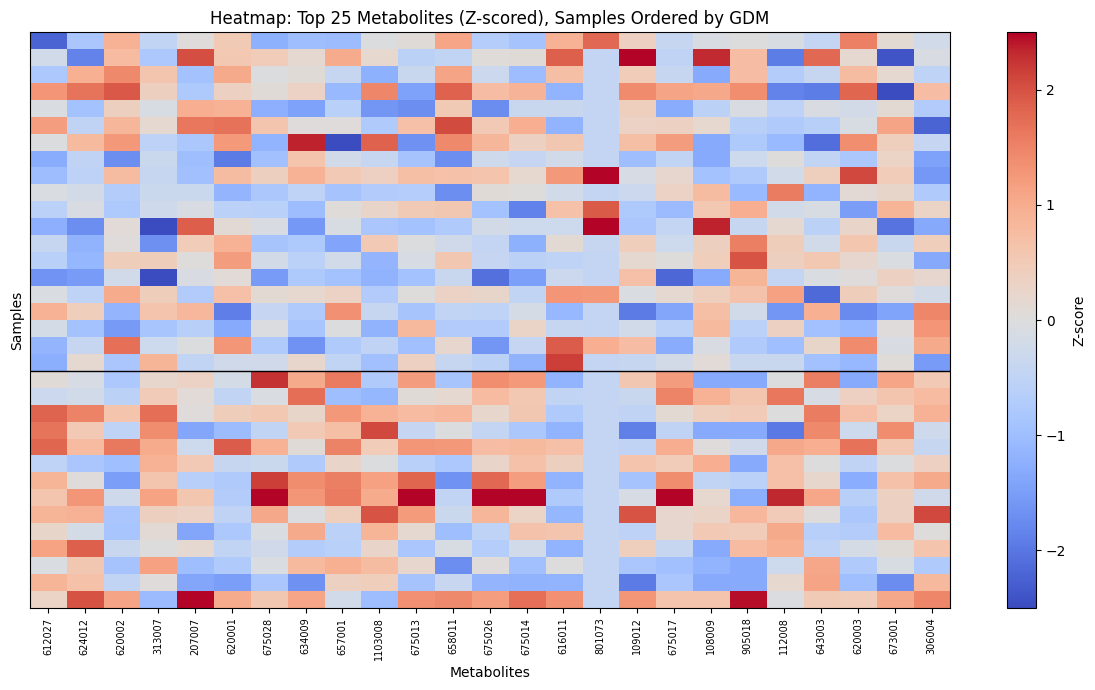

In [168]:
# 5) Heatmap of top 25 metabolites (ranked by raw p-value)
col_lookup = {str(c): c for c in cord_clean.columns}
top25 = viz_df.sort_values("p_value_raw").head(25)["Metabolite"].tolist()
heat_cols = [col_lookup[m] for m in top25 if m in col_lookup]

if not heat_cols:
    print("No overlapping metabolites found between results_df and cord_clean for heatmap.")
else:
    heat_df = cord_clean[heat_cols].copy()
    # Z-score each metabolite to make scales comparable
    heat_z = (heat_df - heat_df.mean()) / heat_df.std(ddof=0).replace(0, np.nan)
    heat_z = heat_z.fillna(0)

    gdm_group = cov_clean.loc[heat_z.index, "GDM"].astype(float).astype(int)
    ordered_idx = gdm_group.sort_values().index
    heat_z = heat_z.loc[ordered_idx]

    fig, ax = plt.subplots(figsize=(12, 7))
    im = ax.imshow(heat_z.values, aspect="auto", cmap="coolwarm", vmin=-2.5, vmax=2.5)
    ax.set_title("Heatmap: Top 25 Metabolites (Z-scored), Samples Ordered by GDM")
    ax.set_xlabel("Metabolites")
    ax.set_ylabel("Samples")
    ax.set_xticks(range(len(heat_cols)))
    ax.set_xticklabels([str(c) for c in heat_cols], rotation=90, fontsize=7)
    ax.set_yticks([])

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Z-score")

    # Mark boundary between Non-GDM and GDM sample blocks
    n_non_gdm = (gdm_group.loc[ordered_idx] == 0).sum()
    ax.axhline(n_non_gdm - 0.5, color="black", linewidth=1)
    plt.tight_layout()
    plt.show()


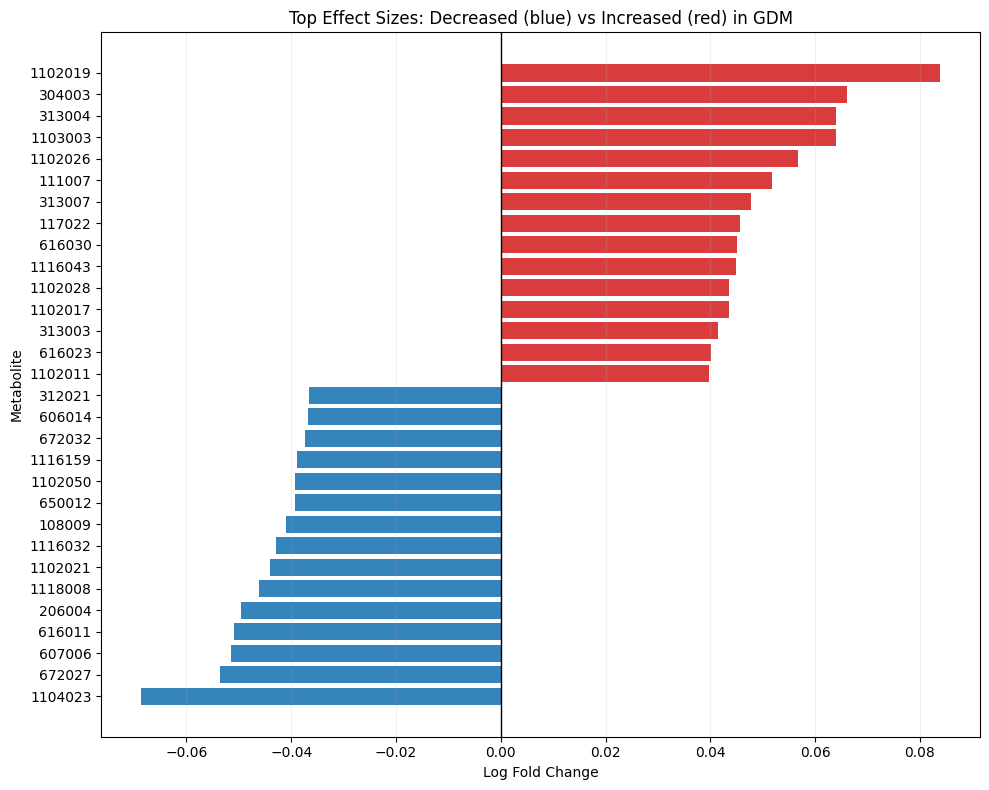

In [169]:
# 6) Ranked effect-size bar plot (largest positive and negative log fold changes)
effect_df = viz_df[["Metabolite", "Log_Fold_Change"]].dropna().copy()

top_pos = effect_df.nlargest(15, "Log_Fold_Change")
top_neg = effect_df.nsmallest(15, "Log_Fold_Change")
bar_df = pd.concat([top_neg, top_pos], axis=0)
bar_df = bar_df.sort_values("Log_Fold_Change")

colors = ["#1f77b4" if v < 0 else "#d62728" for v in bar_df["Log_Fold_Change"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(bar_df["Metabolite"], bar_df["Log_Fold_Change"], color=colors, alpha=0.9)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Log Fold Change")
ax.set_ylabel("Metabolite")
ax.set_title("Top Effect Sizes: Decreased (blue) vs Increased (red) in GDM")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


## Final Conclusion Plot: Significant Difference (GDM Yes/No)

This plot gives a direct answer to the research question using FDR-adjusted significance.


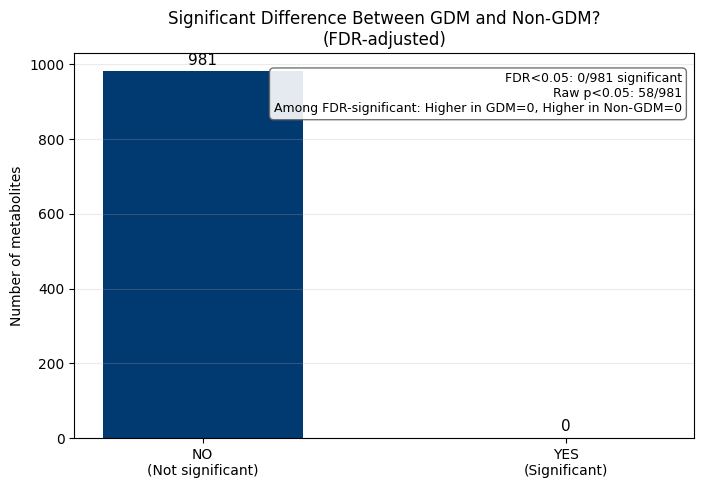

FDR<0.05: 0/981 significant; Raw p<0.05: 58/981.


In [174]:
# Conclusion plot: Does GDM differ from Non-GDM?
alpha = 0.05
summary_df = results_df[["Metabolite", "p_value_raw", "p_value_corrected", "Log_Fold_Change"]].dropna().copy()

n_total = len(summary_df)
summary_df["sig_fdr"] = summary_df["p_value_corrected"] < alpha
summary_df["sig_raw"] = summary_df["p_value_raw"] < alpha

n_sig_fdr = int(summary_df["sig_fdr"].sum())
n_not_sig_fdr = n_total - n_sig_fdr
n_sig_raw = int(summary_df["sig_raw"].sum())

sig_dir = summary_df.loc[summary_df["sig_fdr"]].copy()
n_gdm_higher = int((sig_dir["Log_Fold_Change"] > 0).sum())
n_non_gdm_higher = int((sig_dir["Log_Fold_Change"] < 0).sum())

# Single-panel YES/NO plot for robust notebook rendering
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["NO\n(Not significant)", "YES\n(Significant)"]
counts = [n_not_sig_fdr, n_sig_fdr]
colors = ["#013971", "#d62728"]

bars = ax.bar(labels, counts, color=colors, width=0.55)
ax.set_title("Significant Difference Between GDM and Non-GDM?\n(FDR-adjusted)")
ax.set_ylabel("Number of metabolites")
ax.grid(axis="y", alpha=0.25)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h + max(1, n_total * 0.01), f"{int(h)}",
            ha="center", va="bottom", fontsize=11)

# Add compact interpretation directly in the plot
note = (
    f"FDR<0.05: {n_sig_fdr}/{n_total} significant\n"
    f"Raw p<0.05: {n_sig_raw}/{n_total}\n"
    f"Among FDR-significant: Higher in GDM={n_gdm_higher}, Higher in Non-GDM={n_non_gdm_higher}"
)
ax.text(0.98, 0.95, note, transform=ax.transAxes, ha="right", va="top",
        fontsize=9, bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#666", alpha=0.9))

plt.show()

conclusion_text = f"FDR<0.05: {n_sig_fdr}/{n_total} significant; Raw p<0.05: {n_sig_raw}/{n_total}."
print(conclusion_text)


## Companion Plot: Raw p-value vs FDR Thresholds

This plot compares significance counts under two thresholds:
- Raw `p < 0.05`
- Adjusted `FDR < 0.05`


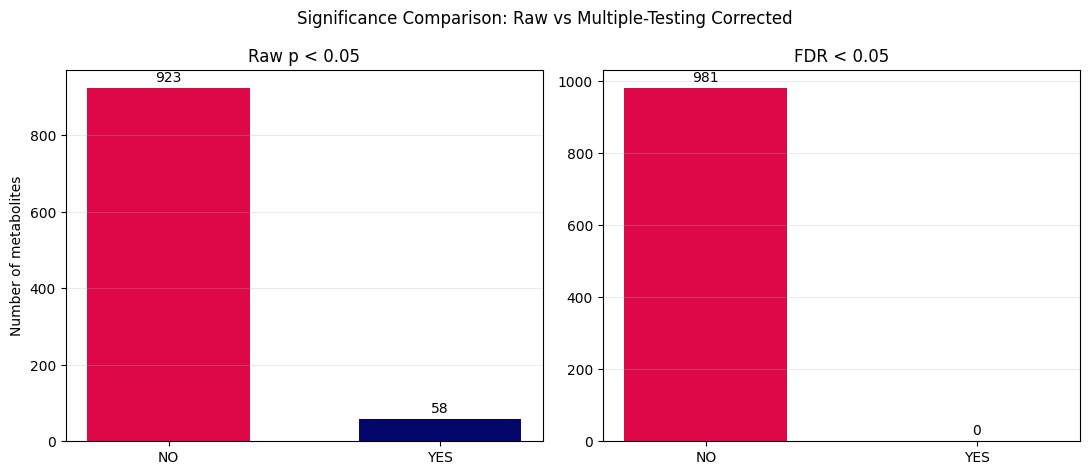

Raw p<0.05: 58/981
FDR<0.05: 0/981


In [180]:
# Side-by-side significance comparison: Raw p<0.05 vs FDR<0.05
alpha = 0.05
cmp_df = results_df[["p_value_raw", "p_value_corrected"]].dropna().copy()

n_total_cmp = len(cmp_df)
raw_yes = int((cmp_df["p_value_raw"] < alpha).sum())
raw_no = n_total_cmp - raw_yes
fdr_yes = int((cmp_df["p_value_corrected"] < alpha).sum())
fdr_no = n_total_cmp - fdr_yes

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Panel 1: Raw p-value threshold
bars1 = axes[0].bar(["NO", "YES"], [raw_no, raw_yes], color=["#de0848", "#04066c"], width=0.6)
axes[0].set_title("Raw p < 0.05")
axes[0].set_ylabel("Number of metabolites")
axes[0].grid(axis="y", alpha=0.25)
for b in bars1:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + max(1, n_total_cmp * 0.01),
                 f"{int(b.get_height())}", ha="center", va="bottom", fontsize=10)

# Panel 2: FDR threshold
bars2 = axes[1].bar(["NO", "YES"], [fdr_no, fdr_yes], color=["#de0848", "#a018d2"], width=0.6)
axes[1].set_title("FDR < 0.05")
axes[1].grid(axis="y", alpha=0.25)
for b in bars2:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + max(1, n_total_cmp * 0.01),
                 f"{int(b.get_height())}", ha="center", va="bottom", fontsize=10)

fig.suptitle("Significance Comparison: Raw vs Multiple-Testing Corrected", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Raw p<0.05: {raw_yes}/{n_total_cmp}")
print(f"FDR<0.05: {fdr_yes}/{n_total_cmp}")
